Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.3614 - loss: 1.8821 - val_accuracy: 0.6034 - val_loss: nan
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.5517 - loss: 1.1919 - val_accuracy: 0.7215 - val_loss: nan
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6466 - loss: 0.9553 - val_accuracy: 0.7426 - val_loss: nan
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7077 - loss: 0.7919 - val_accuracy: 0.7300 - val_loss: nan
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.7204 - loss: 0.7253 - val_accuracy: 0.7553 - val_loss: nan
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.7420 - loss: 0.6918 - val_accuracy: 0.7848 - val_loss: nan
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.7533 - loss: 0.6517 - val_accuracy: 0.7722 - val_loss: nan
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.7726 - loss: 0.6167 - val_accuracy: 0.7806 - val_loss: nan
Epoch

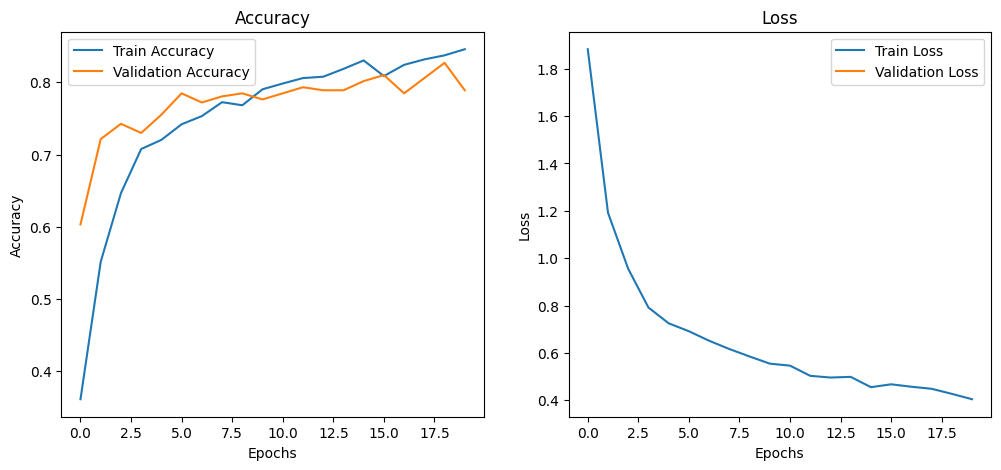

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


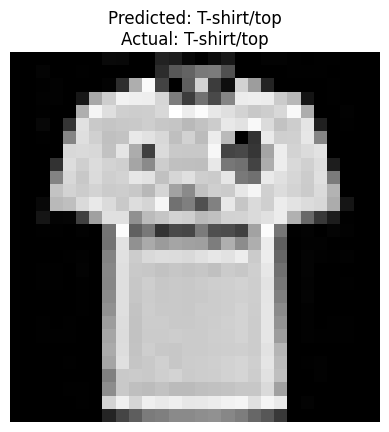

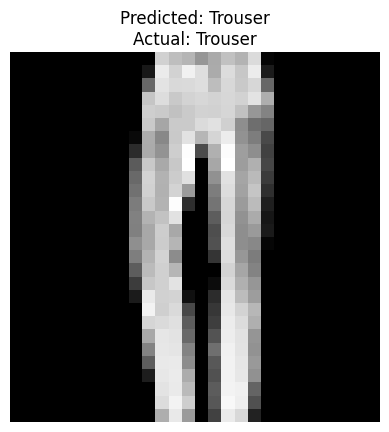

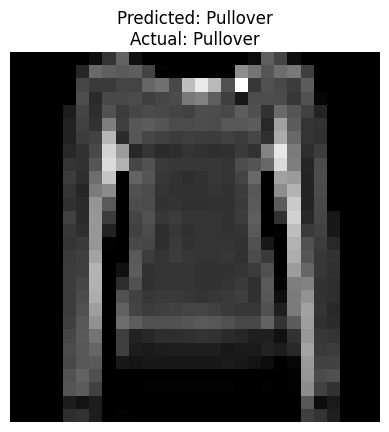

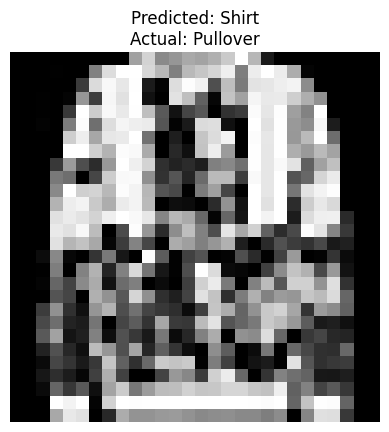

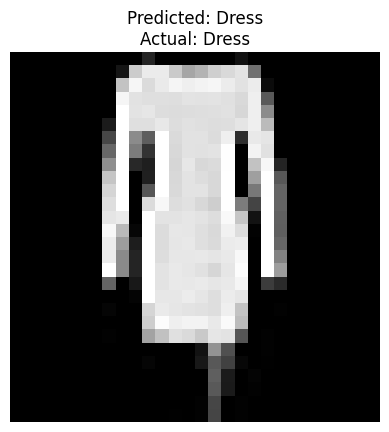

In [ ]:
# -------------------------------
# Import Libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# -------------------------------
# Load Kaggle Dataset (CSV files)
# -------------------------------
train = pd.read_csv("/content/fashion-mnist_train.csv")
test = pd.read_csv("/content/fashion-mnist_test.csv")

# Split features and labels
X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

# -------------------------------
# Preprocessing
# -------------------------------

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN input
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# -------------------------------
# Build CNN Model
# -------------------------------
model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# -------------------------------
# Compile Model
# -------------------------------
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# -------------------------------
# Train Model
# -------------------------------
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split = 0.1
)

# -------------------------------
# Evaluate Model
# -------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_acc)

# -------------------------------
# Plot Accuracy & Loss
# -------------------------------
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# -------------------------------
# Predictions
# -------------------------------
predictions = model.predict(X_test)

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(
        "Predicted: " + class_names[np.argmax(predictions[i])] +
        "\nActual: " + class_names[y_test[i]]
    )
    plt.axis('off')
    plt.show()